# CSED 504 — A2 NLP: From CSED 503 to the token factory

In *hello_text* we built a GPT **by hand** — the causal mask, the attention scores, the softmax,
all spelled out. That is the right way to *learn* what the model does. This notebook is the other
half, the same role `cifar10_train.ipynb` played for Part 1: the **standard, idiomatic workflow**,
where every hand-written piece is replaced by the library (or factory) code that does the same
job — and every replacement is cited back to where you first wrote it in CSED 503.

Nothing here is new *conceptually*. **You have already implemented essentially all of it.**

## Where the old code lives

```
washington/csed503/
    assignment1/  text classification: BoW vectorizers, logistic regression + GD by hand;
                  hyper_sweep.py (the reusable sweep harness)
    assignment2/  n-gram LMs on Shakespeare: <unk> thresholds, add-k, interpolation, PERPLEXITY
    assignment3/  GloVe: cosine similarity, analogies, WEAT, KNN sentence classifiers
    assignment4/  attention from scratch, verified against nn.MultiheadAttention, then plugged
                  into minGPT (gpt-nano) on Shakespeare
    assignment5/  decoding algorithms (greedy/temperature/top-k/top-p) + GPT-2 distillation
```

and one file from 502: `csed502/assignment4/LSTM_Captioning.ipynb`, where you wrote
`lstm_step_forward` and `lstm_step_backward` by hand — the cell that `nn.LSTM` now runs as one
fused cuDNN kernel. These are pointers for *reading*; the notebook is self-contained.

## You already wrote all of this

| Job | What you wrote in CSED 503 | Here |
|-----|---------------------------|------|
| Tokenize text | A2: nltk `word_tokenize` + `<unk>` threshold; A4: custom word tokenizer (count ≥ 3, `<UNK>`/`<PAD>`, `MAX_LEN=100`) | char map + byte-level BPE (`text_prepare.py`) — byte-level means **no `<unk>` exists at all** |
| Batch sequences | A4: truncate/pad every line to 100 tokens | random windows of one flat stream, no padding (`text_data.py`) |
| The LM objective | A2: count-based `P(w \| history)` | next-token cross-entropy (`train_loop.py`) |
| Score a LM | A2: `perplexity()` from scratch | `exp(mean CE)` — the **same number**, same meaning |
| Handle unseen events | A2: add-k, interpolation, `<unk>` | gone: a softmax over 16k byte-level types never assigns zero |
| Attention | A4: `pairwise_similarities`, causal mask, `split_heads`, all by hand | `F.scaled_dot_product_attention` (`models.py`) |
| The recurrent cell | 502 A4: `lstm_step_forward/backward` in numpy | `nn.LSTM` — one fused cuDNN kernel per layer |
| Word vectors | A3: GloVe, downloaded and frozen | `nn.Embedding` trained end-to-end, tied to the softmax head |
| The model | A4: minGPT's `gpt-nano` (3 layers, d48), cloned and configured | `models.py` GPT (d384, 6 layers) + the matched LSTM |
| The training loop | hidden inside minGPT's `Trainer` (A4) and HF `Trainer` (A5) | written out in `train_loop.py` — same `zero_grad / backward / step` |
| Sweeps on real hardware | A1: `hyper_sweep.py` | `train_fleet.py` — one run per GPU, a queue, a dashboard |
| Decoding | A5: greedy, temperature, top-k, top-p against GPT-2 logits | section 7, the same algorithms against **our own** model |

Run order matters only in that section 4 trains the models that section 7 samples from.
Everything finishes in a couple of minutes on one GPU.

In [1]:
# Install the packages. A no-op in the uw-csed504 conda env; on Colab or a fresh setup it pulls
# them in. datasets/tokenizers are the two additions over the a1 stack (see ../a2-nlp/README.md).
%pip install --quiet torch numpy matplotlib tqdm datasets tokenizers

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Pick the best device available and lock the RNGs, exactly as hello_text.ipynb does: the shared
# helper if src/common is reachable, an inline fallback otherwise.
import os, sys

_common = os.path.normpath(os.path.join(os.getcwd(), '../common'))
if os.path.isdir(_common) and _common not in sys.path:
    sys.path.insert(0, _common)

import torch

try:
    from gpu_check import get_device, set_seed
    DEVICE = get_device()
    set_seed(42)
except ImportError:
    import random
    import numpy as np
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    random.seed(42); np.random.seed(42); torch.manual_seed(42)
    print('Device:', DEVICE)

# The same autocast policy as train_run.py: bf16 where the hardware has it (no GradScaler to
# babysit), fp16 elsewhere, nothing on CPU.
USE_AMP = DEVICE.type == 'cuda'
AMP_DTYPE = torch.bfloat16 if (USE_AMP and torch.cuda.is_bf16_supported()) else torch.float16

  PyTorch  : 2.11.0+cu128
  CUDA     : 12.8
  Device   : cuda  [2 GPUs visible - CUDA_VISIBLE_DEVICES='GPU-b09775ec-7817-5003-b4ac-cc406fac5a51,GPU-5b633072-72ed-f715-70ab-c3b32cba0178']
    cuda:0  NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition  sm_120  102.6 GB  <- cuda:0 (primary)
    cuda:1  NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition  sm_120  102.6 GB
  Multi-GPU (2 cards) - pick by goal:
    - FASTER inner loop: stay on ONE card + enable_fast_matmul() + bf16 autocast. DataParallel rarely helps at class model scale
      (comms overhead cancels the 2nd card); measure before relying on it.
    - MORE experiments at once: launch a separate run per card
    - BIGGER model (won't fit on 1 card): device_map="auto", max_memory=get_max_memory()


## 1. Tokenization — `text_prepare.py`

**In CSED 503 this was two different hand-built tokenizers.** A2 used nltk's `word_tokenize`
plus a frequency threshold that replaced rare words with `<unk>`; A4 built a word-level
vocabulary from scratch (`count >= 3`, four special tokens) and padded every line to
`MAX_LEN=100`. Both had the same failure mode: any word not in the vocabulary collapses to
`<unk>`, and the threshold that decides *which* words is a hyperparameter you sweep.

The factory replaces both with two tokenizers, chosen per rung by `text_prepare.py`:

- **Character-level** for the shakespeare rung — literally A4's `sorted(set(text))` trick, kept
  because it is a tokenizer that *cannot* have a bug, which makes this rung the sanity anchor.
- **Byte-level BPE (16,384 merges)** for both wikitext rungs — the GPT-2 scheme. It starts from
  the 256 bytes, so **every string is representable and `<unk>` does not exist**; frequent
  sequences just get merged into single tokens. The A2 problem of unseen words becomes a
  non-problem by construction, not by smoothing.

One decision worth internalizing: **both wikitext rungs share one BPE**, trained once on
wikitext103. Perplexity is `exp(loss per token)`, so it depends on what a "token" is — change
the tokenizer and you change the exam. Sharing the tokenizer is what makes the 2M → 124M token
comparison a *data* comparison and nothing else. (Corollary: none of our numbers compare to
published *word-level* WikiText perplexities, and A2's Shakespeare perplexities — dev ~112 for
the interpolated trigram — were word-level too, so they don't line up with our char-level
numbers either. Same text, different exam.)

And the `imagenet_prepare.py` lesson carries over whole: tokenize **once**, into a flat
`uint16` array on disk, and training never touches raw text or the tokenizer again.

In [3]:
# The dataset ladder, read straight off the stats.json files text_prepare.py wrote -- nothing
# here is typed in by hand, so the table can't go stale.
import json

for name in ('shakespeare', 'wikitext2', 'wikitext103'):
    p = f'data/{name}/stats.json'
    if not os.path.exists(p):
        print(f'{name:12s} not prepared -- run: python text_prepare.py --dataset {name}')
        continue
    s = json.load(open(p))
    n = s['n_tokens']
    print(f"{name:12s} vocab {s['vocab_size']:>6,} ({s['tokenizer']:6s})  "
          f"train {n['train']:>12,} tokens   val {n['val']:>10,}")

# The same sentence through both tokenizers. It is A2's Shakespeare line on purpose.
SENT = 'Whether tis nobler in the mind to suffer'

# Char-level: stoi built from the stored vocab, exactly the CSED 503 dict.
ss = json.load(open('data/shakespeare/stats.json'))
stoi = {ch: i for i, ch in enumerate(ss['vocab'])}
itos = ss['vocab']
char_ids = [stoi[c] for c in SENT]
print(f'\nchar : {len(char_ids):3d} tokens   {char_ids[:12]} ...')

# BPE: the shared 16k tokenizer both wikitext rungs use. In the printed pieces, the G-with-dot
# glyph is the byte-level marker for "this token begins with a space" -- spaces are part of the
# token, not separators between tokens, which is how decode() can be exact.
from tokenizers import Tokenizer
tok = Tokenizer.from_file('data/bpe16k/tokenizer.json')
enc = tok.encode(SENT)
print(f'bpe  : {len(enc.ids):3d} tokens   {enc.tokens}')

# The round trip must be exact -- byte-level BPE is lossless, and if this assert ever fires,
# every perplexity downstream is measuring the wrong text.
assert tok.decode(enc.ids) == SENT
print(f'\nround-trip exact; compression {len(SENT) / len(enc.ids):.1f} chars/token')

shakespeare  vocab     65 (char  )  train    1,003,854 tokens   val     55,770
wikitext2    vocab 16,384 (bpe16k)  train    2,513,191 tokens   val    258,790
wikitext103  vocab 16,384 (bpe16k)  train  123,791,832 tokens   val    258,790

char :  40 tokens   [35, 46, 43, 58, 46, 43, 56, 1, 58, 47, 57, 1] ...
bpe  :  12 tokens   ['W', 'he', 'ther', 'Ġt', 'is', 'Ġnob', 'ler', 'Ġin', 'Ġthe', 'Ġmind', 'Ġto', 'Ġsuffer']

round-trip exact; compression 3.3 chars/token


## 2. Data — `text_data.py`, windows instead of padded lines

**In CSED 503 A4 a batch was made of *lines*:** every Shakespeare line truncated or padded to
100 tokens, with a `<PAD>` token and (in principle) a mask so attention ignores the padding.
That shape came from the *task* (classify/score whole lines), and it wastes compute on padding.

A language model has a simpler option, and it is what minGPT already did under the hood: treat
the whole corpus as **one flat stream** and train on random `seq_len`-token *windows* of it. No
padding, no `<PAD>` token, no wasted positions — every slot of every batch is a real prediction.

The target is the input shifted one place — `y[t]` is the token that follows `x[t]` — which is
exactly the `(x_batch, y_batch)` construction from hello_text, built by slicing one window of
`seq_len+1` tokens instead of stacking two copies.

`GpuTokens` is the whole data stack: the stream lives resident on the GPU (`uint16` on disk,
`int16` on the card — WikiText-103 is ~0.23 GB, nothing next to a1's 3.9 GB), and each batch is
one gather. No `DataLoader`, no workers, no host-to-device copy — the same deletion of the
input pipeline that made Part 1 fast, at 1/17th the size.

In [4]:
import text_data as T

# The train stream for the char rung. seq_len=128 here (the console default is 256): contexts
# this short train visibly in seconds, which is what a teaching notebook wants.
SEQ_LEN = 128
train_ds = T.GpuTokens(DEVICE, 'shakespeare', 'train', seq_len=SEQ_LEN)
val_ds = T.GpuTokens(DEVICE, 'shakespeare', 'val', seq_len=SEQ_LEN)

# One training batch. x and y are (B, T) int64, already on the device.
x, y = next(train_ds.epoch(batch_size=4, train=True))

# Decode the first rows to SEE the objective: y is x slid one character to the left. At every
# position t the model reads x[:t+1] and is scored on producing y[t].
row = lambda t: ''.join(itos[i] for i in t[:56].tolist())
print('x[0]:', repr(row(x[0])))
print('y[0]:', repr(row(y[0])))
print(f'\nshapes x {tuple(x.shape)} y {tuple(y.shape)} | '
      f'{train_ds.n:,} train + {val_ds.n:,} val tokens resident '
      f'({(train_ds.gb() + val_ds.gb()) * 1000:.1f} MB)')

x[0]: '?\n\nELBOW:\nFaith, sir, few of any wit in such matters: as'
y[0]: '\n\nELBOW:\nFaith, sir, few of any wit in such matters: as '

shapes x (4, 128) y (4, 128) | 1,003,854 train + 55,770 val tokens resident (2.1 MB)


## 3. Models — `models.py`

Two families, one per architecture bet, and the CSED 503/502 lineage of each:

- **`gpt`** — A4's project, industrialized. There you wrote `pairwise_similarities`, the causal
  mask, and `split_heads` by hand and verified them against `nn.MultiheadAttention`; here the
  entire mask-softmax-weighted-sum lives inside one call, `F.scaled_dot_product_attention`,
  which picks the FlashAttention kernel when the hardware has it. The block layout (pre-LN,
  residuals, GELU MLP) is hello_text's, and the dims (d384, 6 layers, 6 heads) are **the Part 1
  ViT's on purpose** — same backbone budget, different modality.
- **`lstm`** — 502 A4's `lstm_step_forward`, which you ran once per time step in a Python loop,
  is now one fused cuDNN kernel per *layer* per *sequence*. (One Windows scar to know about:
  the stack is single-layer `nn.LSTM` modules with explicit `nn.Dropout` between them, because
  multi-layer cuDNN dropout allocates a state whose destructor crashes at interpreter exit —
  identical math, cleaner teardown. The comment in `models.py` has the story.)

Both get **tied embeddings** (A3's word vectors, learned end-to-end and shared with the softmax
head), which is why the honest size comparison is **backbone** parameters — the ~6M-parameter
embedding table is identical between them by construction. `lstm_large` and `gpt_medium` are
the capacity controls, Part 1's resnet50/vit_base roles.

In [5]:
import models as M

# The four builders on this rung's vocabulary. The two headliners should match on backbone to
# within a rounding error; the controls should sit at roughly 2x and 3.5x.
print(f"{'builder':12s} {'total':>12s} {'backbone':>12s}")
for name in M.BUILDERS:
    m = M.build(name, train_ds.vocab_size, SEQ_LEN)
    print(f'{name:12s} {M.n_params(m):>12,} {M.n_backbone_params(m):>12,}')

# Build the two headliners for real and check the forward contract: (B, T) token ids in,
# (B, T, vocab) next-token scores out -- the same shape hello_text asserted.
lstm = M.build('lstm', train_ds.vocab_size, SEQ_LEN).to(DEVICE)
gpt = M.build('gpt', train_ds.vocab_size, SEQ_LEN).to(DEVICE)
logits = gpt(x)
assert logits.shape == (*x.shape, train_ds.vocab_size)
print(f'\ngpt(x): {tuple(logits.shape)} -- one score per vocab entry per position')

builder             total     backbone
lstm           10,655,616   10,630,656
gpt            10,714,752   10,640,640
lstm_large     22,987,136   22,962,176
gpt_medium     37,910,016   37,811,200

gpt(x): (4, 128, 65) -- one score per vocab entry per position


## 4. Training — `train_loop.py`, and perplexity is A2's perplexity

**The loop is the one you know** — `zero_grad / backward / step`, the same four lines minGPT's
`Trainer` (A4) and HF's `Trainer` (A5) were running for you out of sight. `train_loop.py`
writes it out once, with the three things a long run needs bolted on: on-GPU metric
accumulation (one host sync per epoch — every `.item()` stalls the pipeline, the lesson that
was worth 7% in Part 1), a loud abort on NaN loss, and atomic checkpoints.

The loss is cross-entropy over every position at once: `(B, T, V)` logits flattened against
`(B*T,)` targets. And the metric is the one A2 taught you:

$$\text{perplexity} = \exp\left(\tfrac{1}{N}\sum_{t} -\log p(w_t \mid w_{<t})\right)$$

A2 computed the inner sum from smoothed n-gram counts; here the $-\log p$ *is* the
cross-entropy the model is trained on. Same number, same meaning — "how many equally-likely
next tokens is the model effectively choosing between" — and **lower is better**, so every
best/regression comparison in the factory is flipped relative to Part 1's accuracy.

Below we train both headliners for a few epochs with the *actual factory functions* — the same
`train_one_epoch` and `evaluate` the console runs use, minus the warmup/cosine schedule and
checkpointing that only matter at full length.

In [6]:
import torch.nn as nn
import train_loop as E

# Family recipes, the same split train_run.py wires up: AdamW for both, but the transformer gets
# the GPT constants (lower LR, real weight decay). A constant LR is fine for a 6-epoch demo; the
# console adds the warmup-then-cosine schedule, and a transformer's warmup is NOT optional at
# full scale.
EPOCHS, BATCH = 6, 64
RECIPES = {'lstm': dict(lr=1e-3, weight_decay=0.0),
           'gpt': dict(lr=3e-4, weight_decay=0.1, betas=(0.9, 0.95))}

runs = {}
for name, model in (('lstm', lstm), ('gpt', gpt)):
    torch.manual_seed(42)
    opt = torch.optim.AdamW(model.parameters(), **RECIPES[name])
    criterion = nn.CrossEntropyLoss()
    # The scaler only matters on the fp16 fallback path; under bf16 it is constructed disabled,
    # exactly as in train_run.py.
    scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP and AMP_DTYPE is torch.float16)

    hist = []
    for epoch in range(1, EPOCHS + 1):
        tr = E.train_one_epoch(model, train_ds, opt, criterion, scaler, DEVICE, BATCH,
                               epoch, EPOCHS, use_amp=USE_AMP, amp_dtype=AMP_DTYPE, clip=1.0)
        va = E.evaluate(model, val_ds, criterion, DEVICE, batch_size=BATCH,
                        use_amp=USE_AMP, amp_dtype=AMP_DTYPE)
        hist.append({'train': tr, 'val': va})
        print(f"{name:5s} epoch {epoch}/{EPOCHS}  train ppl {tr['ppl']:7.2f}  "
              f"val ppl {va['ppl']:7.2f}  ({tr['tok_s']/1e3:5.0f}k tok/s)")
    runs[name] = hist

lstm  epoch 1/6  train ppl    8.51  val ppl    6.08  (  456k tok/s)


lstm  epoch 2/6  train ppl    5.16  val ppl    4.98  (  576k tok/s)


lstm  epoch 3/6  train ppl    4.52  val ppl    4.62  (  577k tok/s)


lstm  epoch 4/6  train ppl    4.19  val ppl    4.48  (  578k tok/s)


lstm  epoch 5/6  train ppl    4.02  val ppl    4.31  (  579k tok/s)


...

gpt   epoch 2/6  train ppl   10.19  val ppl    8.91  (  963k tok/s)


gpt   epoch 3/6  train ppl    8.12  val ppl    7.36  (  987k tok/s)


gpt   epoch 4/6  train ppl    6.62  val ppl    6.44  (  960k tok/s)


gpt   epoch 5/6  train ppl    5.78  val ppl    5.88  (  980k tok/s)


gpt   epoch 6/6  train ppl    5.27  val ppl    5.41  (  975k tok/s)


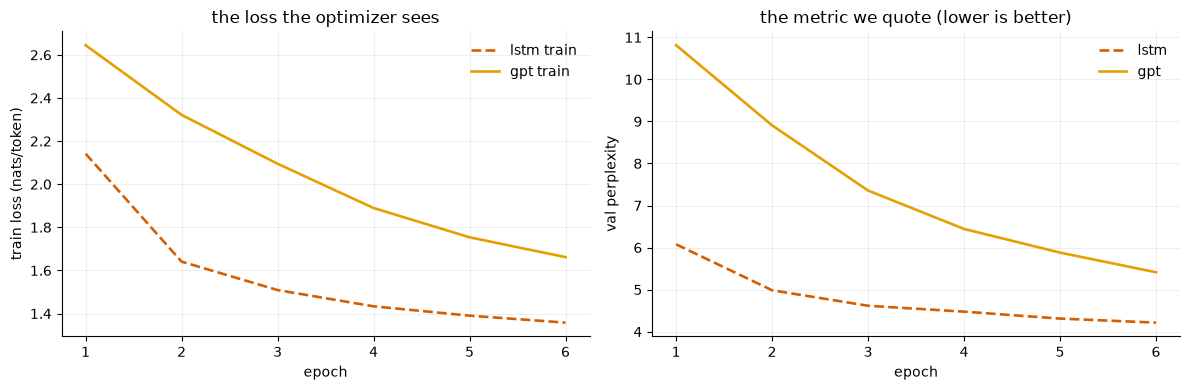

In [7]:
# The two learning curves. Same palette rules as every chart in this project: the models being
# compared share the dataset's hue and differ in shade (lstm darker, gpt lighter), dashed
# against solid says lstm against gpt a second way.
import matplotlib.pyplot as plt

STYLE = {'lstm': ('#D55E00', '--'), 'gpt': ('#E69F00', '-')}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for name, hist in runs.items():
    color, ls = STYLE[name]
    eps = range(1, len(hist) + 1)
    ax1.plot(eps, [h['train']['loss'] for h in hist], color=color, linestyle=ls,
             linewidth=1.9, label=f'{name} train')
    ax2.plot(eps, [h['val']['ppl'] for h in hist], color=color, linestyle=ls,
             linewidth=1.9, label=name)

ax1.set_xlabel('epoch'); ax1.set_ylabel('train loss (nats/token)')
ax1.set_title('the loss the optimizer sees')
ax2.set_xlabel('epoch'); ax2.set_ylabel('val perplexity')
ax2.set_title('the metric we quote (lower is better)')
for ax in (ax1, ax2):
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 5. The A2 anchor — beat the counting model or go home

A2's whole arc was count-based models: unigram → n-gram → smoothed → interpolated, each scored
by perplexity. Those models cost nothing to "train" (they are counting), which makes them the
perfect floor: **any neural model that cannot beat a counting model at that scale is not
learning anything worth the electricity.** The study keeps this as a permanent reference line.

Here is A2's unigram model with add-1 smoothing, in four lines of torch instead of a Python
loop over a counts dict — same model, same math.

In [8]:
# A2's unigram LM: P(w) = (count(w) + 1) / (N + V), perplexity on the val split. bincount over
# the resident stream is the entire "training".
counts = torch.bincount(train_ds.t.long(), minlength=train_ds.vocab_size).float()
probs = (counts + 1) / (counts.sum() + train_ds.vocab_size)
unigram_ppl = torch.exp(-probs[val_ds.t.long()].log().mean()).item()

best_neural = {name: min(h['val']['ppl'] for h in hist) for name, hist in runs.items()}
print(f'unigram (add-1) val ppl : {unigram_ppl:7.2f}   <- the A2 floor')
for name, ppl in best_neural.items():
    print(f'{name:5s} (6 epochs) val ppl : {ppl:7.2f}')
print('\nA2 note: its Shakespeare perplexities were word-level (interpolated trigram ~112 dev);')
print('these are char-level, so the NUMBERS do not compare -- only the ranking game does.')

unigram (add-1) val ppl :   28.01   <- the A2 floor
lstm  (6 epochs) val ppl :    4.21
gpt   (6 epochs) val ppl :    5.41

A2 note: its Shakespeare perplexities were word-level (interpolated trigram ~112 dev);
these are char-level, so the NUMBERS do not compare -- only the ranking game does.


## 6. The console factory — `train_run.py`, `train_fleet.py`, `dashboard.py`

Part 1's split, kept on purpose: **this notebook is the fast path** (watch the pipeline work,
minutes); **the console is the real path** (every quoted number). The pieces, and where each
idea came from:

- **`train_run.py`** — one process, one GPU, one model. The full recipe (warmup → cosine,
  grad clip 1.0 for *both* families — standard LM practice, so it can't tilt the race the way
  clipping tilted Part 1's ResNet-18), a checkpoint every epoch, `--resume`, and one JSONL row
  per epoch. Tags are `<dataset>_<model>[_sN]`, and smoke tests get a `smoke-` prefix that
  cannot be escaped — the trap where a 2-epoch smoke run once appended junk to a real run's
  history is fenced off by construction.
- **`train_fleet.py`** — A1's `hyper_sweep.py`, grown up: a queue of runs, one per card,
  refill the moment a card frees up. `--queue seeds` is the Part 1 lesson (a single run's gap
  can be pure noise — three seeds per arm before quoting a winner); `--queue overnight` adds
  the capacity controls.
- **`dashboard.py`** — read-only: it watches `runs/*.jsonl` and the tqdm tail of
  `logs/*.log`, never the processes. Perplexity falls, so a healthy sparkline slopes down, and
  the overfit grade is the val/train perplexity *ratio*.

The cell below reads whatever real runs exist in `runs/` right now — the same files the
dashboard and (eventually) the results notebook read. After tonight's fleet it will fill in.

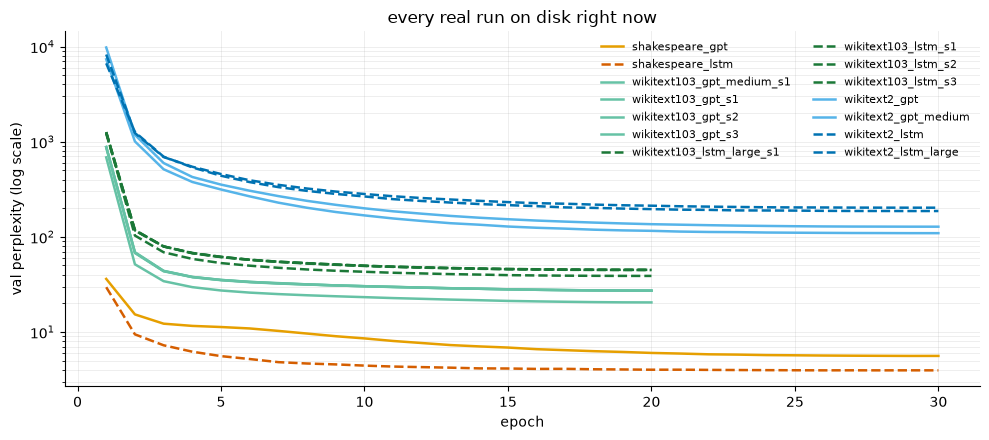


run                        best val ppl  epochs       params  minutes
shakespeare_lstm                   3.95      30   10,655,616      1.1
shakespeare_gpt                    5.60      30   10,763,904      0.5
wikitext103_gpt_medium_s1         20.45      20   46,330,880     73.1
wikitext103_gpt_s3                27.18      20   17,030,400     75.6
wikitext103_gpt_s2                27.19      20   17,030,400     63.9
wikitext103_gpt_s1                27.20      20   17,030,400     55.7
wikitext103_lstm_large_s1         38.83      20   29,253,632     17.1
wikitext103_lstm_s1               44.74      20   16,922,112     64.4
wikitext103_lstm_s2               44.93      20   16,922,112     60.2
wikitext103_lstm_s3               45.04      20   16,922,112     60.3
wikitext2_gpt_medium             109.29      30   46,330,880      5.0
wikitext2_gpt                    127.85      30   17,030,400      2.6
wikitext2_lstm_large             186.70      30   29,253,632      3.7
wikitext2_lstm     

In [9]:
# Every non-smoke run on disk: curves from runs/*.jsonl, scoreboard from runs/*_result.json.
# Dataset picks the hue, family picks the shade, dashed = lstm, solid = gpt -- the exact scheme
# of dashboard.py and the Part 1 report.
import glob

PALETTE = {'shakespeare': ('#D55E00', '#E69F00'),
           'wikitext2': ('#0072B2', '#56B4E9'),
           'wikitext103': ('#1B7837', '#66C2A5')}

fig, ax = plt.subplots(figsize=(10, 4.5))
found = []
for path in sorted(glob.glob('runs/*.jsonl')):
    tag = os.path.basename(path)[:-6]
    if tag.startswith('smoke-'):
        continue
    rows = [json.loads(l) for l in open(path) if l.strip()]
    if not rows:
        continue
    dataset = tag.split('_')[0]
    dark, light = PALETTE.get(dataset, ('#666666', '#aaaaaa'))
    is_gpt = '_gpt' in tag
    ax.plot(range(1, len(rows) + 1), [r['val']['ppl'] for r in rows],
            color=light if is_gpt else dark, linestyle='-' if is_gpt else '--',
            linewidth=1.8, label=tag)
    found.append(tag)

if found:
    ax.set_yscale('log')
    ax.set_xlabel('epoch'); ax.set_ylabel('val perplexity (log scale)')
    ax.set_title('every real run on disk right now')
    ax.grid(alpha=0.25, linewidth=0.6, which='both')
    ax.legend(frameon=False, fontsize=8, ncol=2)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout(); plt.show()
else:
    plt.close(fig)
    print('no console runs on disk yet -- run: python train_fleet.py --queue shakespeare')

# The scoreboard, straight off the result files.
results = []
for path in sorted(glob.glob('runs/*_result.json')):
    if os.path.basename(path).startswith('smoke-'):
        continue
    d = json.load(open(path))
    results.append(d)
if results:
    print(f"\n{'run':26s} {'best val ppl':>12s} {'epochs':>7s} {'params':>12s} {'minutes':>8s}")
    for d in sorted(results, key=lambda r: (r['dataset'], r['best_ppl'])):
        print(f"{d['tag']:26s} {d['best_ppl']:12.2f} {d['epochs']:7d} "
              f"{d['params']:12,} {d['seconds']/60:8.1f}")

## 7. Decoding — A5's algorithms against our own model

A5 had you implement the decoding zoo — greedy, vanilla sampling, temperature, top-k, top-p —
against a pretrained GPT-2's logits. The algorithms don't care whose logits they steer, so here
they are again (compressed into one function) driving the model *you just trained*, plus the
console-trained checkpoint when it exists.

The behaviors to look for are the ones A5 measured: **greedy** commits to the argmax and tends
to loop (its generations scored a degenerate perplexity of ~2 in A5 — fluent-looking, no
information); **temperature < 1** sharpens toward greedy; **temperature > 1** flattens toward
noise; **top-k** cuts the long tail off before sampling. hello_text's `generate` was
temperature-only — this is the rest of the zoo.

In [10]:
import torch.nn.functional as F

@torch.no_grad()
def generate(model, idx, max_new, temperature=1.0, top_k=None, seq_len=SEQ_LEN):
    """A5's decoding algorithms in one loop: temperature=0 means greedy; top_k, when set,
    keeps only the k highest-scoring tokens before sampling."""
    model.eval()
    for _ in range(max_new):
        logits = model(idx[:, -seq_len:])[:, -1, :]      # scores for the next token only
        if temperature == 0.0:
            nxt = logits.argmax(-1, keepdim=True)         # greedy: the committed choice
        else:
            logits = logits / temperature
            if top_k:
                kth = logits.topk(top_k).values[..., -1, None]
                logits = logits.masked_fill(logits < kth, float('-inf'))
            nxt = torch.multinomial(F.softmax(logits, -1), 1)
        idx = torch.cat([idx, nxt], 1)
    return idx

# Prefer the console-trained 30-epoch checkpoint (runs/shakespeare_lstm.pt, gitignored but
# present after any real run); fall back to this notebook's 6-epoch model on a fresh clone.
sampler, label, gen_len = lstm, 'notebook lstm (6 epochs)', SEQ_LEN
ck_path = 'runs/shakespeare_lstm.pt'
if os.path.exists(ck_path):
    ck = torch.load(ck_path, map_location=DEVICE)
    sampler = M.build('lstm', train_ds.vocab_size, 256).to(DEVICE)
    sampler.load_state_dict(ck['model'])
    label, gen_len = f"console lstm ({ck['epoch']} epochs, best val ppl {ck['best']:.2f})", 256
print(f'sampling from: {label}\n')

prompt = torch.tensor([[stoi[c] for c in 'ROMEO:']], device=DEVICE)
for temp, k, desc in ((0.0, None, 'greedy -- watch it commit and repeat'),
                      (0.8, 40, 'temperature 0.8 + top-k 40 -- the usual sweet spot'),
                      (1.4, None, 'temperature 1.4 -- flattened toward noise')):
    out = generate(sampler, prompt, 200, temperature=temp, top_k=k, seq_len=gen_len)
    print(f"--- {desc}\n{''.join(itos[i] for i in out[0].tolist())}\n")

sampling from: console lstm (30 epochs, best val ppl 3.95)

--- greedy -- watch it commit and repeat
ROMEO:
I will not see the sea to the prince of the world.

KING RICHARD III:
What is the sea that was the state of the world
Which they shall be so so so sound to the sea,
And then the state of the state of

--- temperature 0.8 + top-k 40 -- the usual sweet spot
ROMEO:
Do not show me!

JOHN OF GAUNT:
Why, then I be so heard hear them speak;
And what thou leave me such a lamb of leave,
And let him yield a soul that they cannot be
Again to sake, for we will serve the

--- temperature 1.4 -- flattened toward noise
ROMEO:
Nay, by, with him? All these is he?

Second Murderer:
Plantagenet; my good gracious Season!
And! i' the gioln coom! damnedly 'shoned agent,
For-need find notible o'er Juliet the wat
Of freiendssion, 



---

## Where this leaves you

Each factory file, and the 503 concept it industrializes:

| file | is the grown-up version of |
|---|---|
| `text_prepare.py` | A2/A4's tokenizers + vocab dicts (and a1's tokenize-once lesson) |
| `text_data.py` | A4's padded batches, replaced by windows over one GPU-resident stream |
| `models.py` | A4's hand attention + minGPT; 502 A4's LSTM cell, fused by cuDNN |
| `train_loop.py` | the loop minGPT/HF `Trainer` hid, plus perplexity from A2 |
| `train_run.py` / `train_fleet.py` | A1's `hyper_sweep.py`, one run per GPU with seeds |
| `dashboard.py` | watching it all, read-only |

The study itself runs from the console (see `README.md` for tonight's queues), and its results
land in `runs/` — which section 6 of this notebook, the dashboard, and the eventual results
notebook all read from the same files.